In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [3]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [19]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 1.348, Train Metric: 0.912, Valid Metric: 0.895
Epoch: 2/20, Loss: 1.211, Train Metric: 0.868, Valid Metric: 0.841
Epoch: 3/20, Loss: 0.974, Train Metric: 0.774, Valid Metric: 0.708
Epoch: 4/20, Loss: 0.689, Train Metric: 0.639, Valid Metric: 0.596
Epoch: 5/20, Loss: 0.591, Train Metric: 0.576, Valid Metric: 0.569
Epoch: 6/20, Loss: 0.567, Train Metric: 0.559, Valid Metric: 0.544
Epoch: 7/20, Loss: 0.55, Train Metric: 0.548, Valid Metric: 0.571
Epoch: 8/20, Loss: 0.534, Train Metric: 0.538, Valid Metric: 0.54
Epoch: 9/20, Loss: 0.521, Train Metric: 0.531, Valid Metric: 0.519
Epoch: 10/20, Loss: 0.512, Train Metric: 0.525, Valid Metric: 0.537
Epoch: 11/20, Loss: 0.501, Train Metric: 0.518, Valid Metric: 0.508
Epoch: 12/20, Loss: 0.494, Train Metric: 0.514, Valid Metric: 0.517
Epoch: 13/20, Loss: 0.488, Train Metric: 0.51, Valid Metric: 0.508
Epoch: 14/20, Loss: 0.483, Train Metric: 0.508, Valid Metric: 0.498
Epoch: 15/20, Loss: 0.481, Train Metric: 0.505, Valid Metric

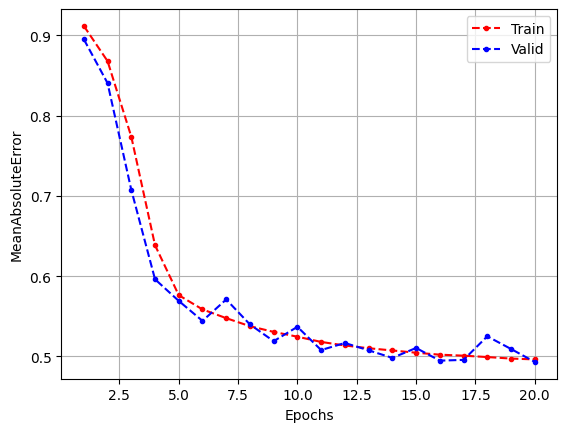

In [20]:
learning_rate = 0.01
n_epochs=20


model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.Sigmoid(),
	nn.Linear(in_features=30, out_features=50), 
	nn.Sigmoid(),
	nn.Linear(in_features=50, out_features=1)
).to(device)
# class PriceRegressor(nn.Module):
# 	def __init__(self, n_features=8):
# 		super().__init__()
# 		self.stack = nn.Sequential(
# 			nn.Linear(in_features=n_features, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=1)
# 		)
        
# 	def forward(self, X):
# 		y = self.stack(X)
# 		return y
# model = PriceRegressor().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

In [21]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.477


In [23]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.inference_mode():
	y_pred = model(X_new)

y_pred[:5]

tensor([[1.8381],
        [2.4349],
        [1.5174],
        [3.0415],
        [2.3595]])

In [24]:
sum([param.numel() for param in model.parameters()])

1871